In [1]:
%matplotlib inline

(-0.5, 639.5, 479.5, -0.5)

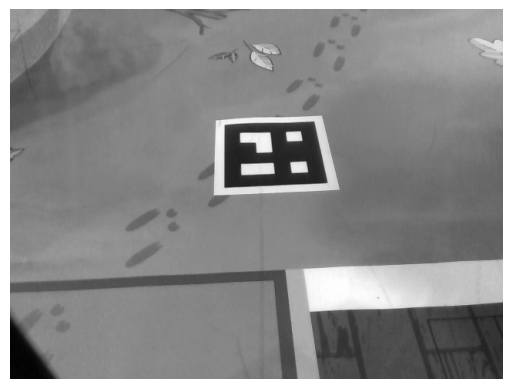

In [2]:
# load image using opencv
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an image using OpenCV
image = cv2.imread('img.png')

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image using matplotlib
plt.imshow(gray_image, cmap='gray')
plt.axis('off')  # Hide the axis

In [3]:
aruco_dictionary = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_parameters =  cv2.aruco.DetectorParameters()
aruco_detector = cv2.aruco.ArucoDetector(aruco_dictionary, aruco_parameters)

markerCorners, markerIds, _ = aruco_detector.detectMarkers(image)

print(markerCorners)
print(markerIds)

(array([[[412., 225.],
        [278., 231.],
        [279., 150.],
        [394., 146.]]], dtype=float32),)
[[21]]


In [4]:
cameraMatrix = np.array([
    [610.3757934570312, 0, 318.8870544433594],
    [0, 609.22705078125, 246.54132080078125],
    [0, 0, 1]
    ])
distCoeffs = np.array([0, 0, 0, 0, 0])

rvec, tvec, markerPoints = cv2.aruco.estimatePoseSingleMarkers(markerCorners, 0.1, cameraMatrix=cameraMatrix, distCoeffs=distCoeffs)

print("tvec:", tvec)
print("rvec:", rvec)

tvec: [[[ 0.01745525 -0.04951802  0.49137783]]]
rvec: [[[ 0.07274914  2.90450545 -1.18883973]]]


(-0.5, 639.5, 479.5, -0.5)

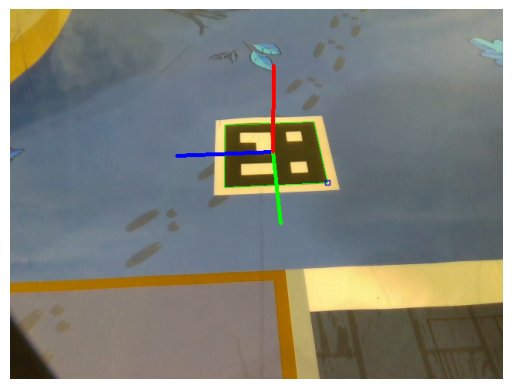

In [5]:
cv2.aruco.drawDetectedMarkers(image, markerCorners)
cv2.drawFrameAxes(image, cameraMatrix, distCoeffs, rvec, tvec, 0.1) 

plt.imshow(image, cmap='gray')
plt.axis('off')  # Hide the axis

In [6]:
import cv2
import numpy as np
from scipy.spatial.transform import Rotation as R

# 1. Flatten the nested arrays OpenCV returns
rvec_flat = np.squeeze(rvec[0])
tvec_flat = np.squeeze(tvec[0])
tx, ty, tz = tvec_flat

# 2. Convert OpenCV Rodrigues to a Scipy Rotation object
rot_matrix, _ = cv2.Rodrigues(rvec_flat)
r_orig = R.from_matrix(rot_matrix)

# 3. Create the additional -90 degree Yaw rotation (around local Z-axis)
r_yaw_offset = R.from_euler('z', -90, degrees=True)

# 4. Multiply to apply the rotation to the local frame
# Multiplying on the right (r_orig * r_yaw_offset) applies it locally
r_final = r_orig * r_yaw_offset

# 5. Extract the final quaternion
qx, qy, qz, qw = r_final.as_quat()

# 6. Generate the exact command for your terminal
ros_command = (
    f"ros2 run tf2_ros static_transform_publisher "
    f"{tx:.5f} {ty:.5f} {tz:.5f} "
    f"{qx:.5f} {qy:.5f} {qz:.5f} {qw:.5f} "
    f"camera_color_optical_frame aruco_cam"
)

print("Run this command:")
print(ros_command)

Run this command:
ros2 run tf2_ros static_transform_publisher 0.01746 -0.04952 0.49138 -0.63785 0.67062 -0.26862 -0.26695 camera_color_optical_frame aruco_cam


In [ ]:
# Then, say you have the robot 45.75m away from the aruco. Then, run:

# ros2 run tf2_ros static_transform_publisher 0.4575 0 0 3.14159 0 0 aruco_cam base_link2

# Finally, run this to get the transform you need to put in the URDF

# ros2 run tf2_ros tf2_echo base_link2 camera_link

# Tests bird view (verify it's not distorted)

In [33]:
# import cv2
# import numpy as np

# # 1. Define the desired size of the output bird's-eye image
# output_size = 500  # 500x500 pixels
# dst_points = np.array([
#     [0, 0],
#     [output_size - 1, 0],
#     [output_size - 1, output_size - 1],
#     [0, output_size - 1]
# ], dtype="float32")

# # 2. Extract corners for the first detected marker
# # markerCorners is the list returned by detectMarkers()
# if len(markerCorners) > 0:
#     # We take the corners of the first marker [0]
#     # reshaped to (4, 2)
#     src_points = markerCorners[0].reshape(4, 2)

#     # 3. Compute the Perspective Transform Matrix
#     M = cv2.getPerspectiveTransform(src_points, dst_points)

#     # 4. Apply the transformation to the original image
#     birds_eye = cv2.warpPerspective(image, M, (output_size, output_size))

#     # Display results
#     cv2.imshow("Original", image)
#     cv2.imshow("Bird's Eye View", birds_eye)
#     cv2.waitKey(0)

In [7]:
print(60-28.5/2)

45.75
